# West Gardar dolerite dykes ca. 1271 Ma paleomagnetic pole

## Geologic context

The West Gardar dolerite dykes belong to the Gardar igneous province of South
Greenland, an intracontinental alkaline rift province. Piper & Stearn (1977)
sampled the Gardar dyke swarms and reported site-mean directions; the
dolerite dykes carry a shallow, northwest-directed magnetization. The dykes
are near-vertical intrusions and require no tilt correction.

## Pole

This notebook recreates the dolerite-dyke pole at the dyke level as the Fisher
mean of the 24 site virtual geomagnetic poles (VGPs) of Piper & Stearn
(1977). The site table archives directions only (no per-site coordinates), so VGPs
are computed at the sampling locality (61.2 deg N, 311.7 deg E). As a
Laurentia-Greenland pole it is shown rotated into the Laurentia reference frame
(using the Greenland Euler pole of `pole_tools`) in the APWP-context and
pole-overlap plots.

## Age constraints

- Nominal age 1271 Ma (bounds 1263-1278 Ma). Piper & Stearn (1977) cite Patchett &
  Upton (1977) -- a study that was never published -- for Rb-Sr biotite ages of
  1278, 1277, 1272, 1265, and 1263 Ma on the Gardar dolerite dykes. These are
  adopted as the age bounds, with their average (1271 Ma) as the nominal age.
  Because the only control is unpublished Rb-Sr biotite cooling ages, the age is
  poorly constrained.

## References

- Paleomagnetic source and age constraint: Piper, J. D. A., & Stearn, J. E. F. (1977). Palaeomagnetism of the dyke swarms of the
  Gardar igneous province, south Greenland. *Physics of the Earth and Planetary
  Interiors*, 14(4), 345-358. https://doi.org/10.1016/0031-9201(77)90167-4

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Loaded from `../data/1244_West_Gardar_dolerite/`. The contribution stores site-mean directions
only (Piper & Stearn, 1977), so a virtual geomagnetic pole is computed for each
dyke at the common sampling locality (61.2 deg N, 311.7 deg E) with
`pmag.dia_vgp`.

In [2]:
sites = pd.read_csv('../data/1244_West_Gardar_dolerite/sites.txt', sep='\t', skiprows=1)
dyke = sites[sites['result_quality'] == 'g'].reset_index(drop=True)
study_lat, study_lon = 61.2, 311.7

# directions only in the contribution -> compute each dyke's VGP at the locality
vgp_lon, vgp_lat = [], []
for _, r in dyke.iterrows():
    a95 = r['dir_alpha95'] if pd.notna(r['dir_alpha95']) else 5.0
    plon, plat, dp, dm = pmag.dia_vgp(r['dir_dec'], r['dir_inc'], a95, study_lat, study_lon)
    vgp_lon.append(round(plon, 1)); vgp_lat.append(round(plat, 1))
dyke = dyke.assign(vgp_lon=vgp_lon, vgp_lat=vgp_lat)
print(f'{len(dyke)} dolerite dykes')
dyke[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

24 dolerite dykes


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,1,274.8,32.3,38,11.0,6,17.6,226.2
1,3,303.0,-7.4,44,10.2,6,11.8,190.5
2,4,288.9,-33.2,78,7.6,6,-7.1,196.7
3,6,292.5,-39.2,64,8.5,6,-9.2,191.8
4,7,300.8,21.6,43,10.4,6,24.3,199.3
5,9,316.4,-21.1,105,6.6,6,10.2,175.2
6,10,290.0,41.2,55,9.1,6,30.2,216.3
7,11,299.2,11.7,247,4.9,5,18.9,198.3
8,18,281.5,11.9,241,4.3,6,10.8,214.5
9,22,292.7,11.8,146,6.4,5,16.0,204.4


## Mean pole from site VGPs

The directions form a single, near-horizontal northwest-directed cluster (shallow,
low paleolatitude), so the mean direction is computed without polarity
unification. Because the inclinations straddle the horizontal, the corresponding
site VGPs fall into two near-antipodal groups; the pole is therefore the Fisher
mean of the VGPs after uniting their polarity.

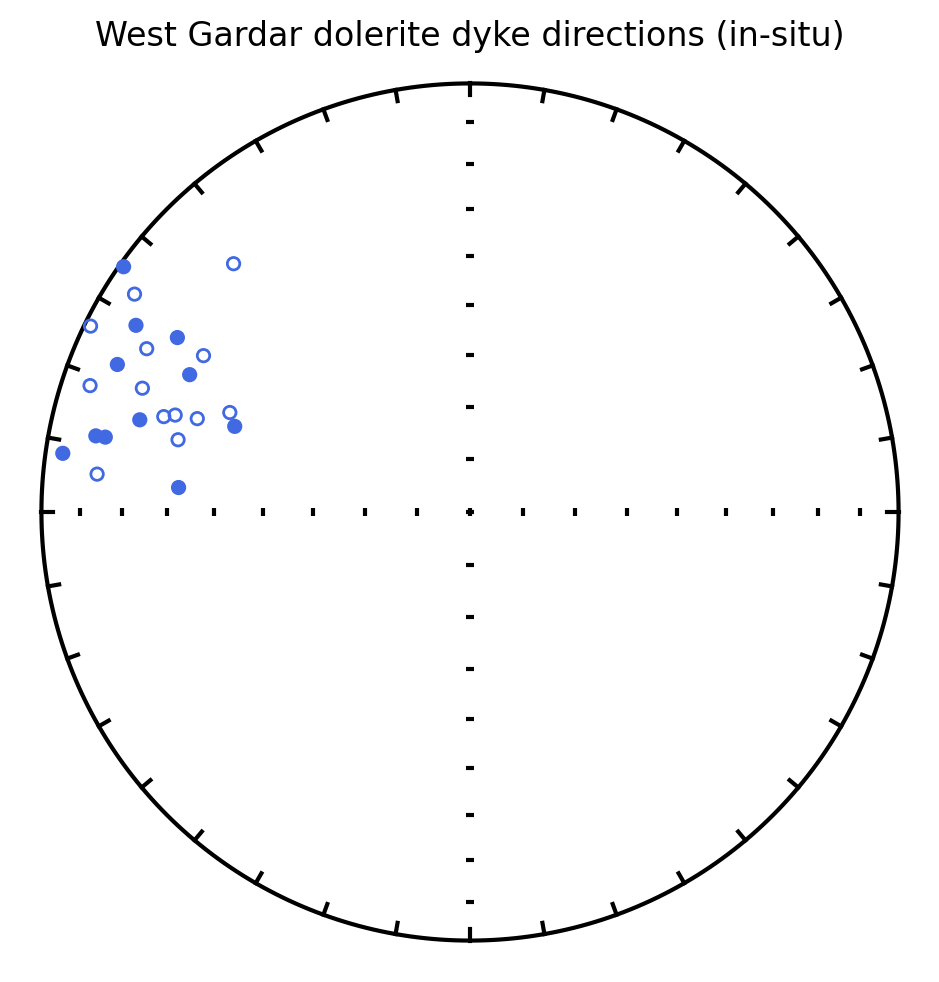

Plon: 201.9  Plat: 8.6
Number of directions in mean (n): 24
Angular radius of 95% confidence (A_95): 5.9
Precision parameter (k) estimate: 26.3

Piper & Stearn (1977) / prior compilation pole: 8.7 N / 201.7 E, A95 6.6


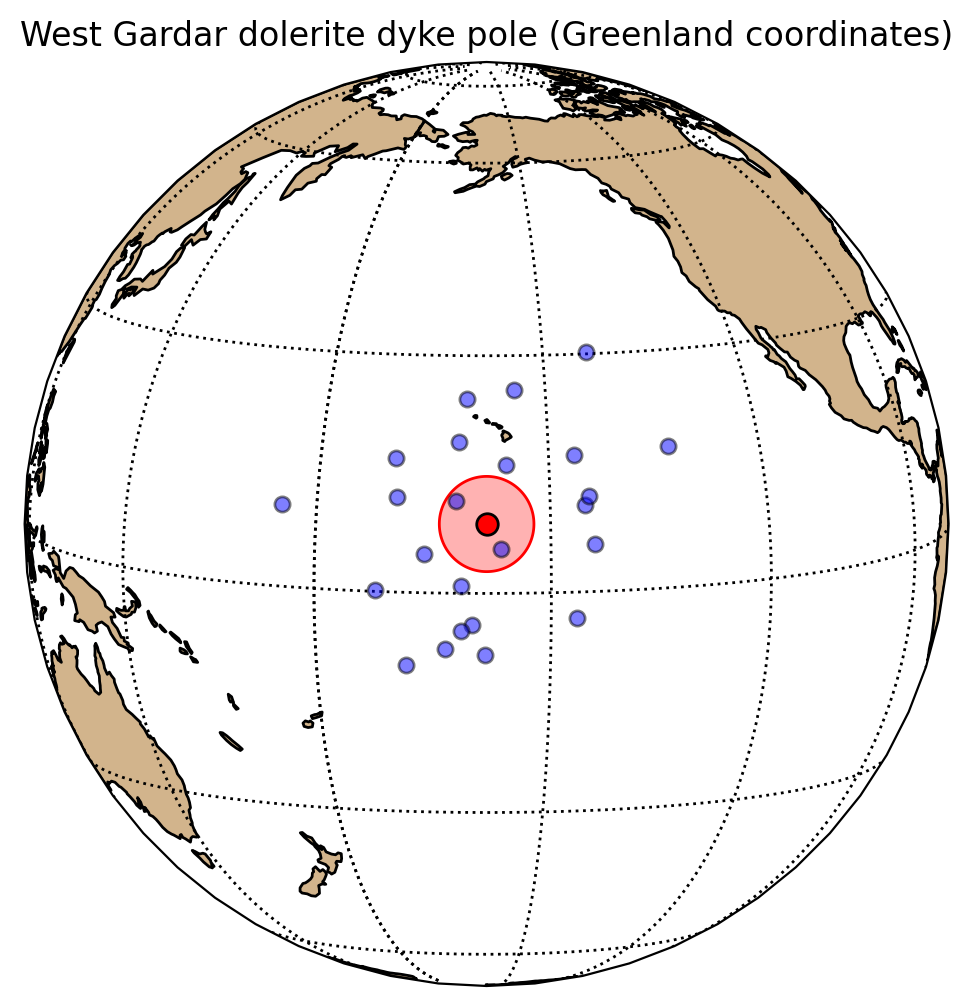

In [3]:
ipmag.plot_net()
ipmag.plot_di(dyke['dir_dec'].tolist(), dyke['dir_inc'].tolist(), color='royalblue', marker='o')
plt.title('West Gardar dolerite dyke directions (in-situ)')
plt.show()

vgp_block, pole_mean = pt.compute_mean_pole(dyke, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nPiper & Stearn (1977) / prior compilation pole: 8.7 N / 201.7 E, A95 6.6')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('West Gardar dolerite dyke pole (Greenland coordinates)')
plt.show()

## Mean direction

Dec: 291.5  Inc: -3.2
Number of directions in mean (n): 24
Angular radius of 95% confidence (a_95): 9.4
Precision parameter (k) estimate: 10.8
Piper & Stearn (1977) mean direction: 291.5/-3.3


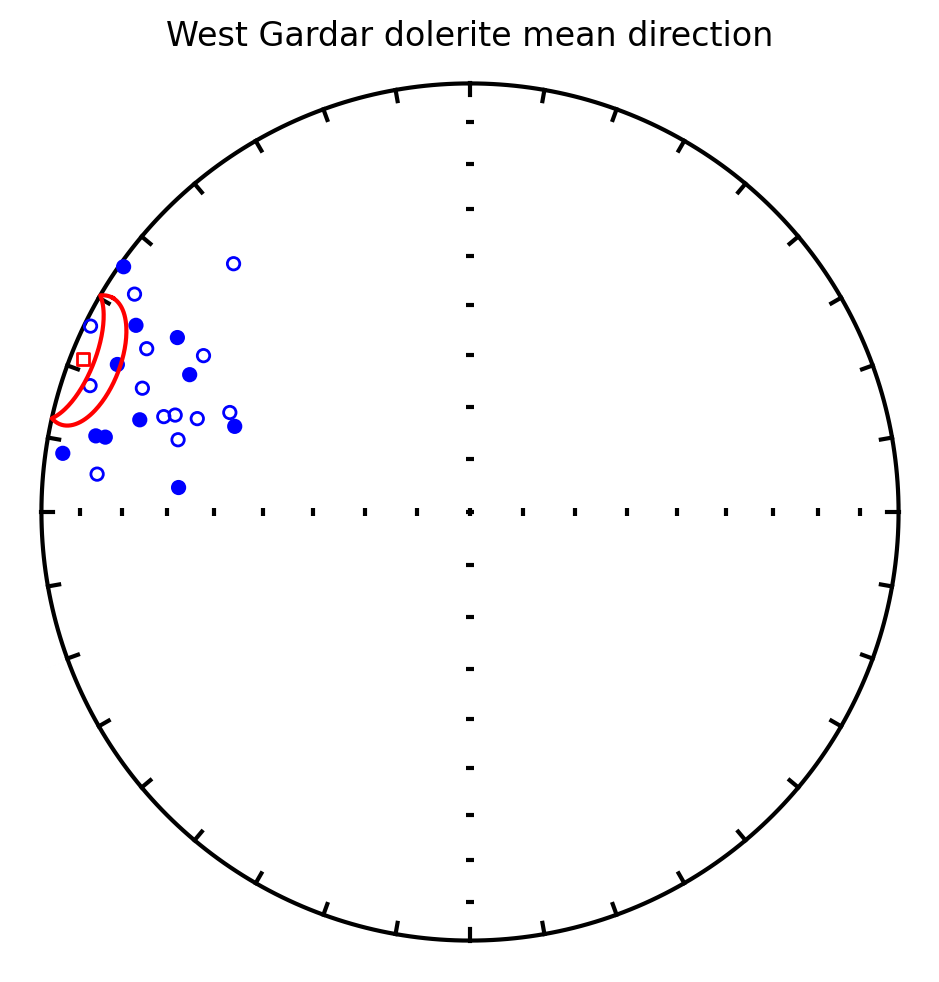

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(dyke, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
print('Piper & Stearn (1977) mean direction: 291.5/-3.3')
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('West Gardar dolerite mean direction')
plt.show()

## Paleosecular variation

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: no
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 138 samples (>= 25): PASS
        K = 26.3 (10-70): PASS
        B = 24 sites (>= 8): PASS
        min 5 samples/site (>= 3): PASS
        A95 = 5.9 in Deenen envelope [3.4, 11.1]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 5.9 passes Deenen et al. (2011) criteria of being between 3.4 and 11.1 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

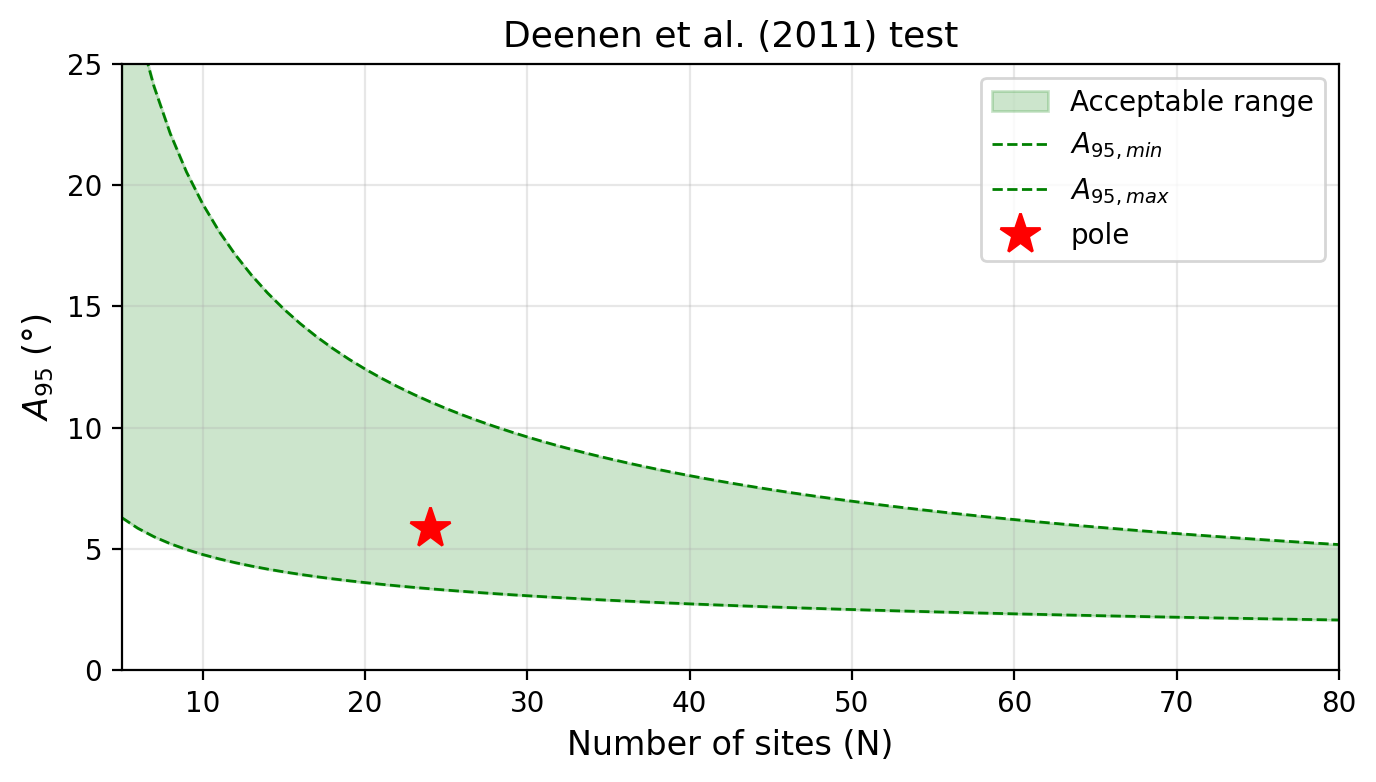

In [5]:
r2 = pt.assess_R2(dyke, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are Fisher
distributed, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD model expectation at the sampling
paleolatitude.

{'Mode': 'Mode 1',
 'Dec': 201.9325266162385,
 'Inc': 8.577915544155232,
 'N': 24,
 'Mu': 0.7942711397266232,
 'Mu_critical': 1.207,
 'Me': 1.1061663905460855,
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

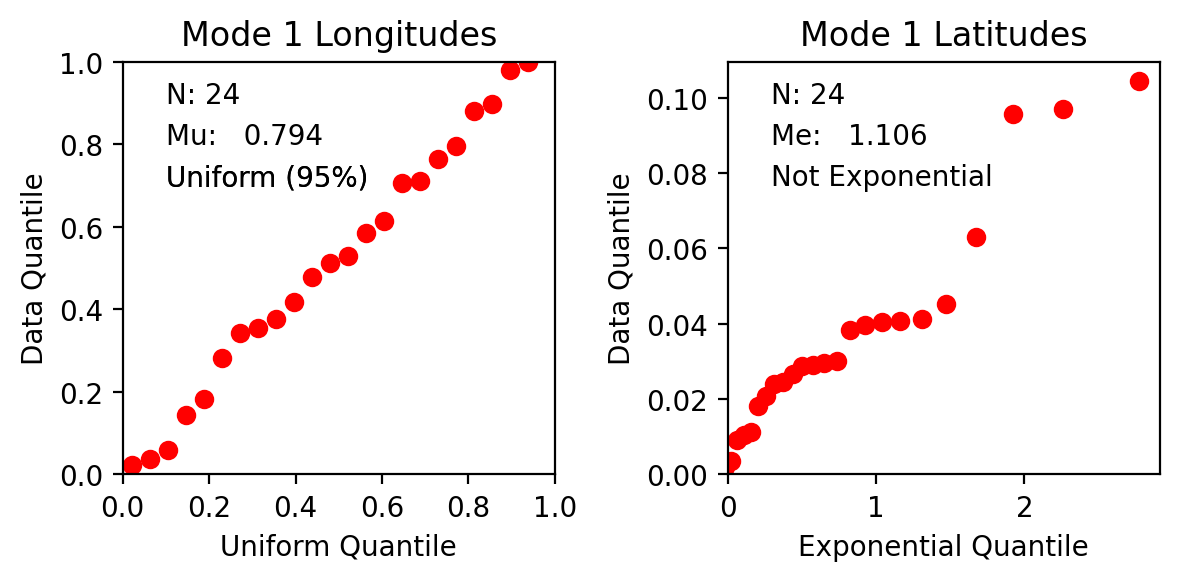

In [6]:
fishqq_result = pt.fishqq_vgps(dyke, unify_polarity=True)
fishqq_result

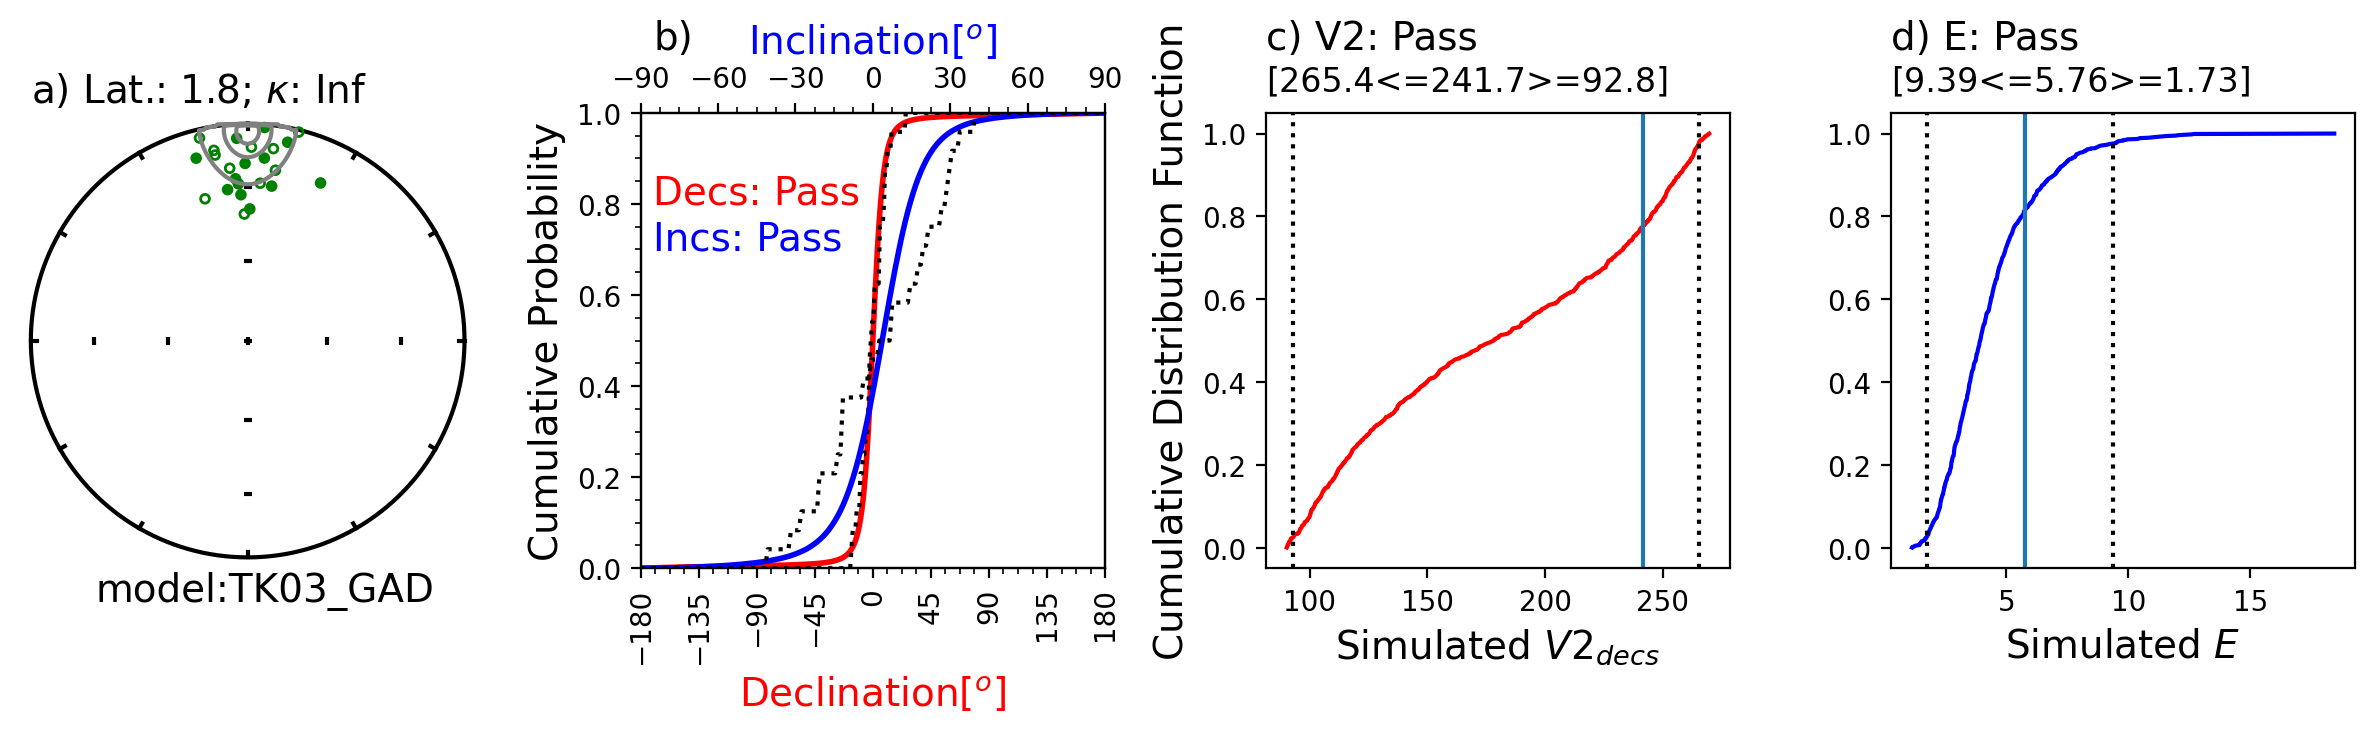

paleolatitude = 1.8 deg; elongation E = 5.76 (consistent with TK03.GAD)


In [7]:
try:
    svei_result = pt.svei_test_vgps(dyke, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(dyke, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

The site VGPs are not Fisher-distributed (Fisher Q-Q rejected) and the directional distribution is strongly elongated, as expected for a shallow, near-equatorial population; at the implied paleolatitude (~2 deg) the TK03.GAD model bounds are very wide, so the elongation is not formally inconsistent with the model.

## The West Gardar pole in the context of the Laurentia APWP

As a Laurentia-Greenland pole it is rotated into the Laurentia reference frame with the Greenland Euler pole used by `pole_tools.get_Laurentia_poles`.

pole in Laurentia frame: 12.4 N / 189.9 E, A95 5.9


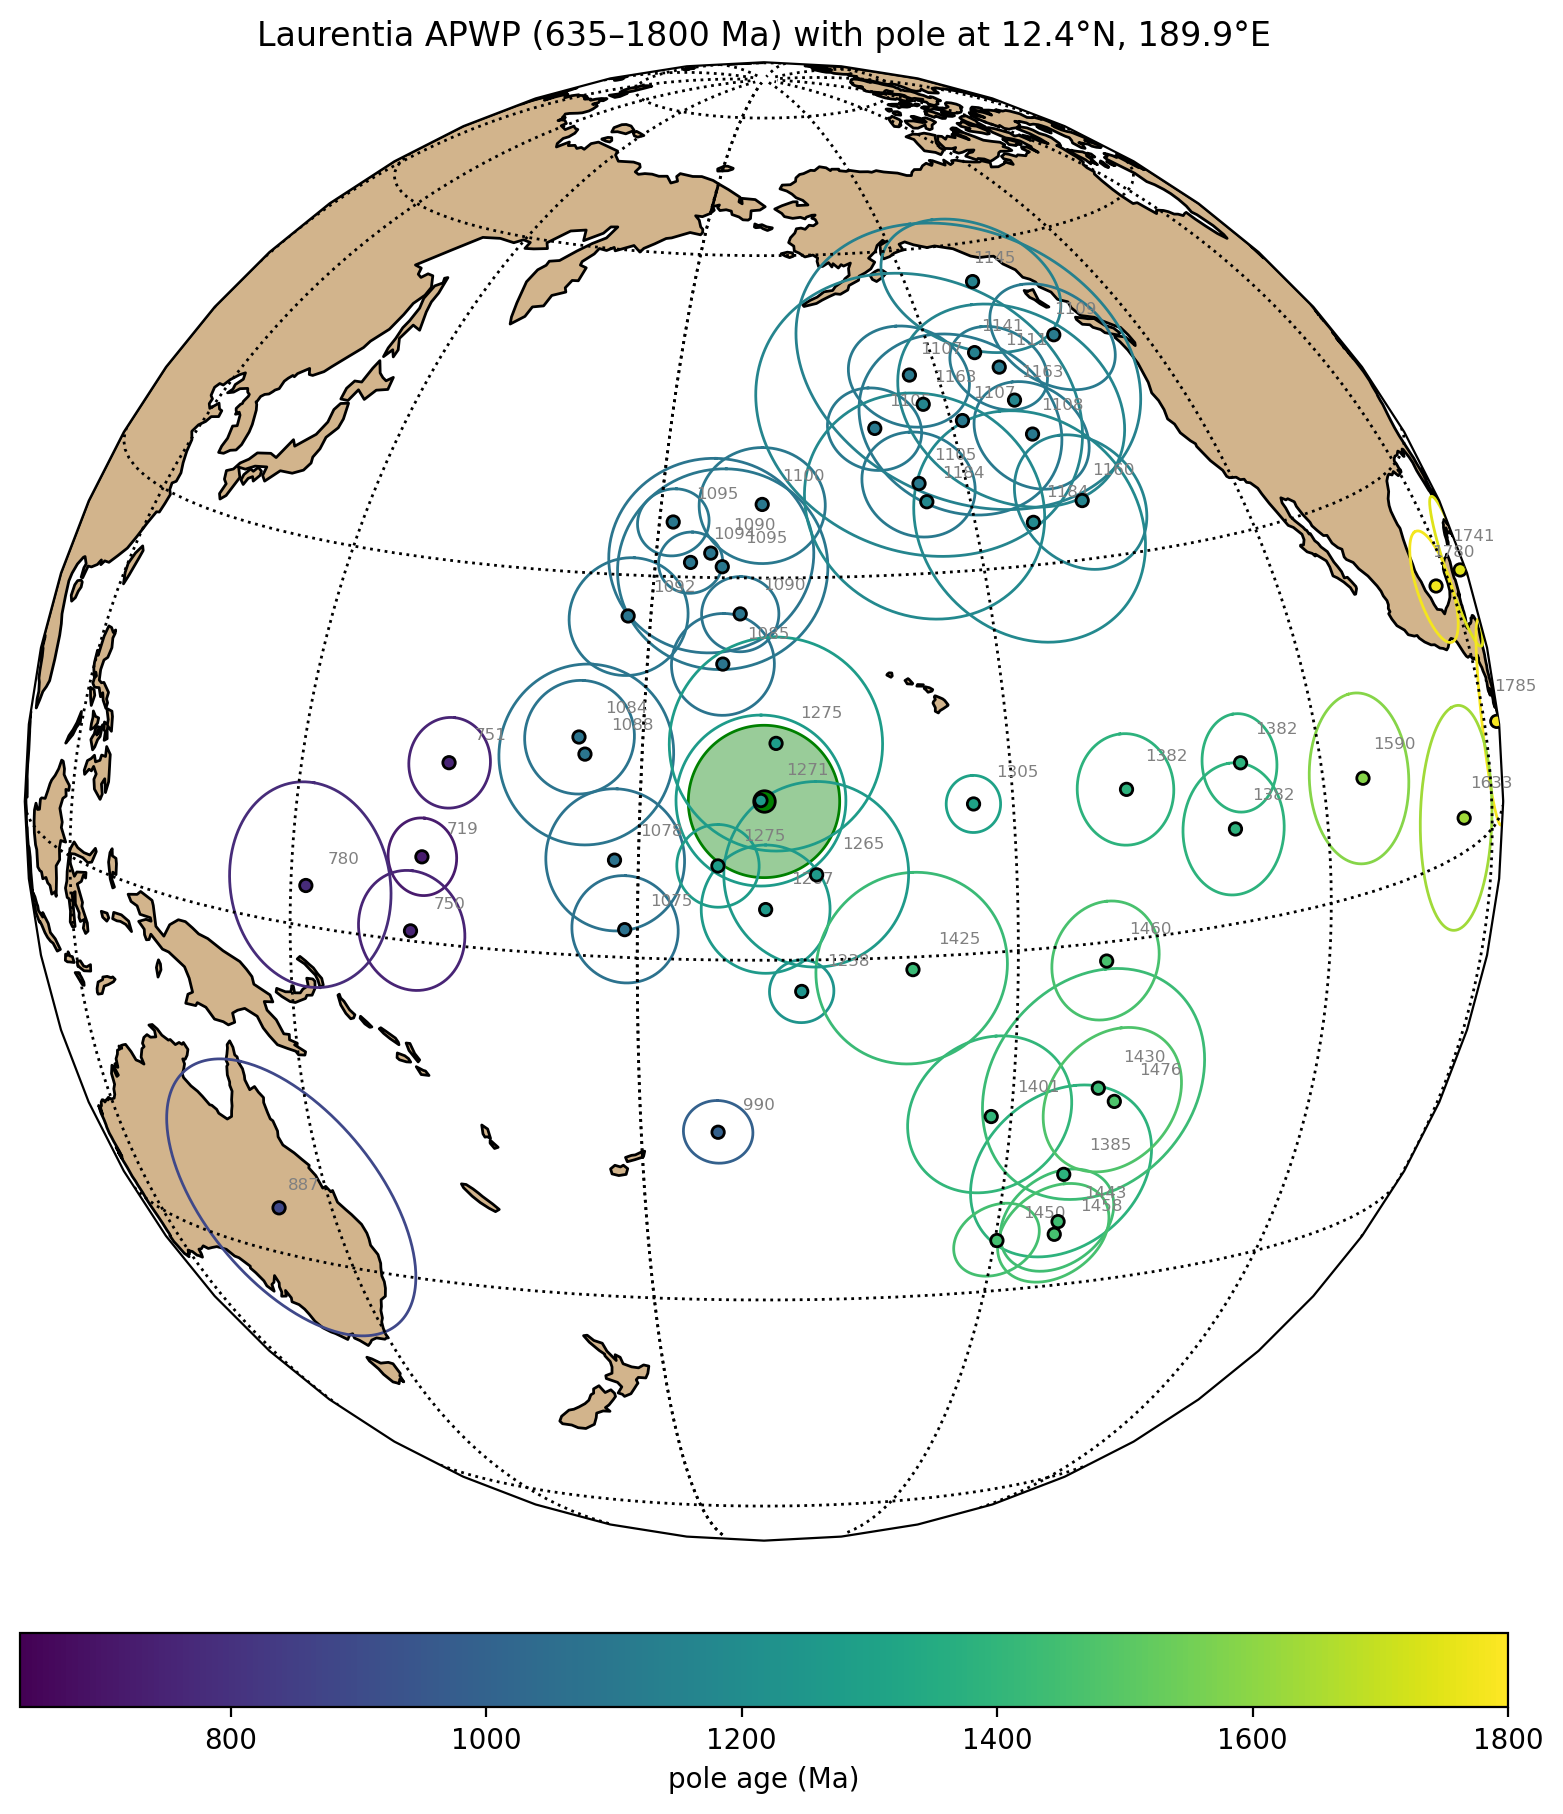

In [8]:
# rotate the Greenland-coordinate pole into the Laurentia reference frame
EULER_GREENLAND = [67.5, -118.5, -13.8]   # pole_tools Laurentia-Greenland Euler pole
_rlat, _rlon = pmag.pt_rot(EULER_GREENLAND, [pole_mean['inc']], [pole_mean['dec']])
pole_rot = {'inc': _rlat[0], 'dec': _rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"pole in Laurentia frame: {pole_rot['inc']:.1f} N / {pole_rot['dec']:.1f} E, A95 {pole_rot['alpha95']:.1f}")

Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_rot['inc'], pole_rot['dec'],
                          pole_rot['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rot['dec'],
                          central_latitude=pole_rot['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

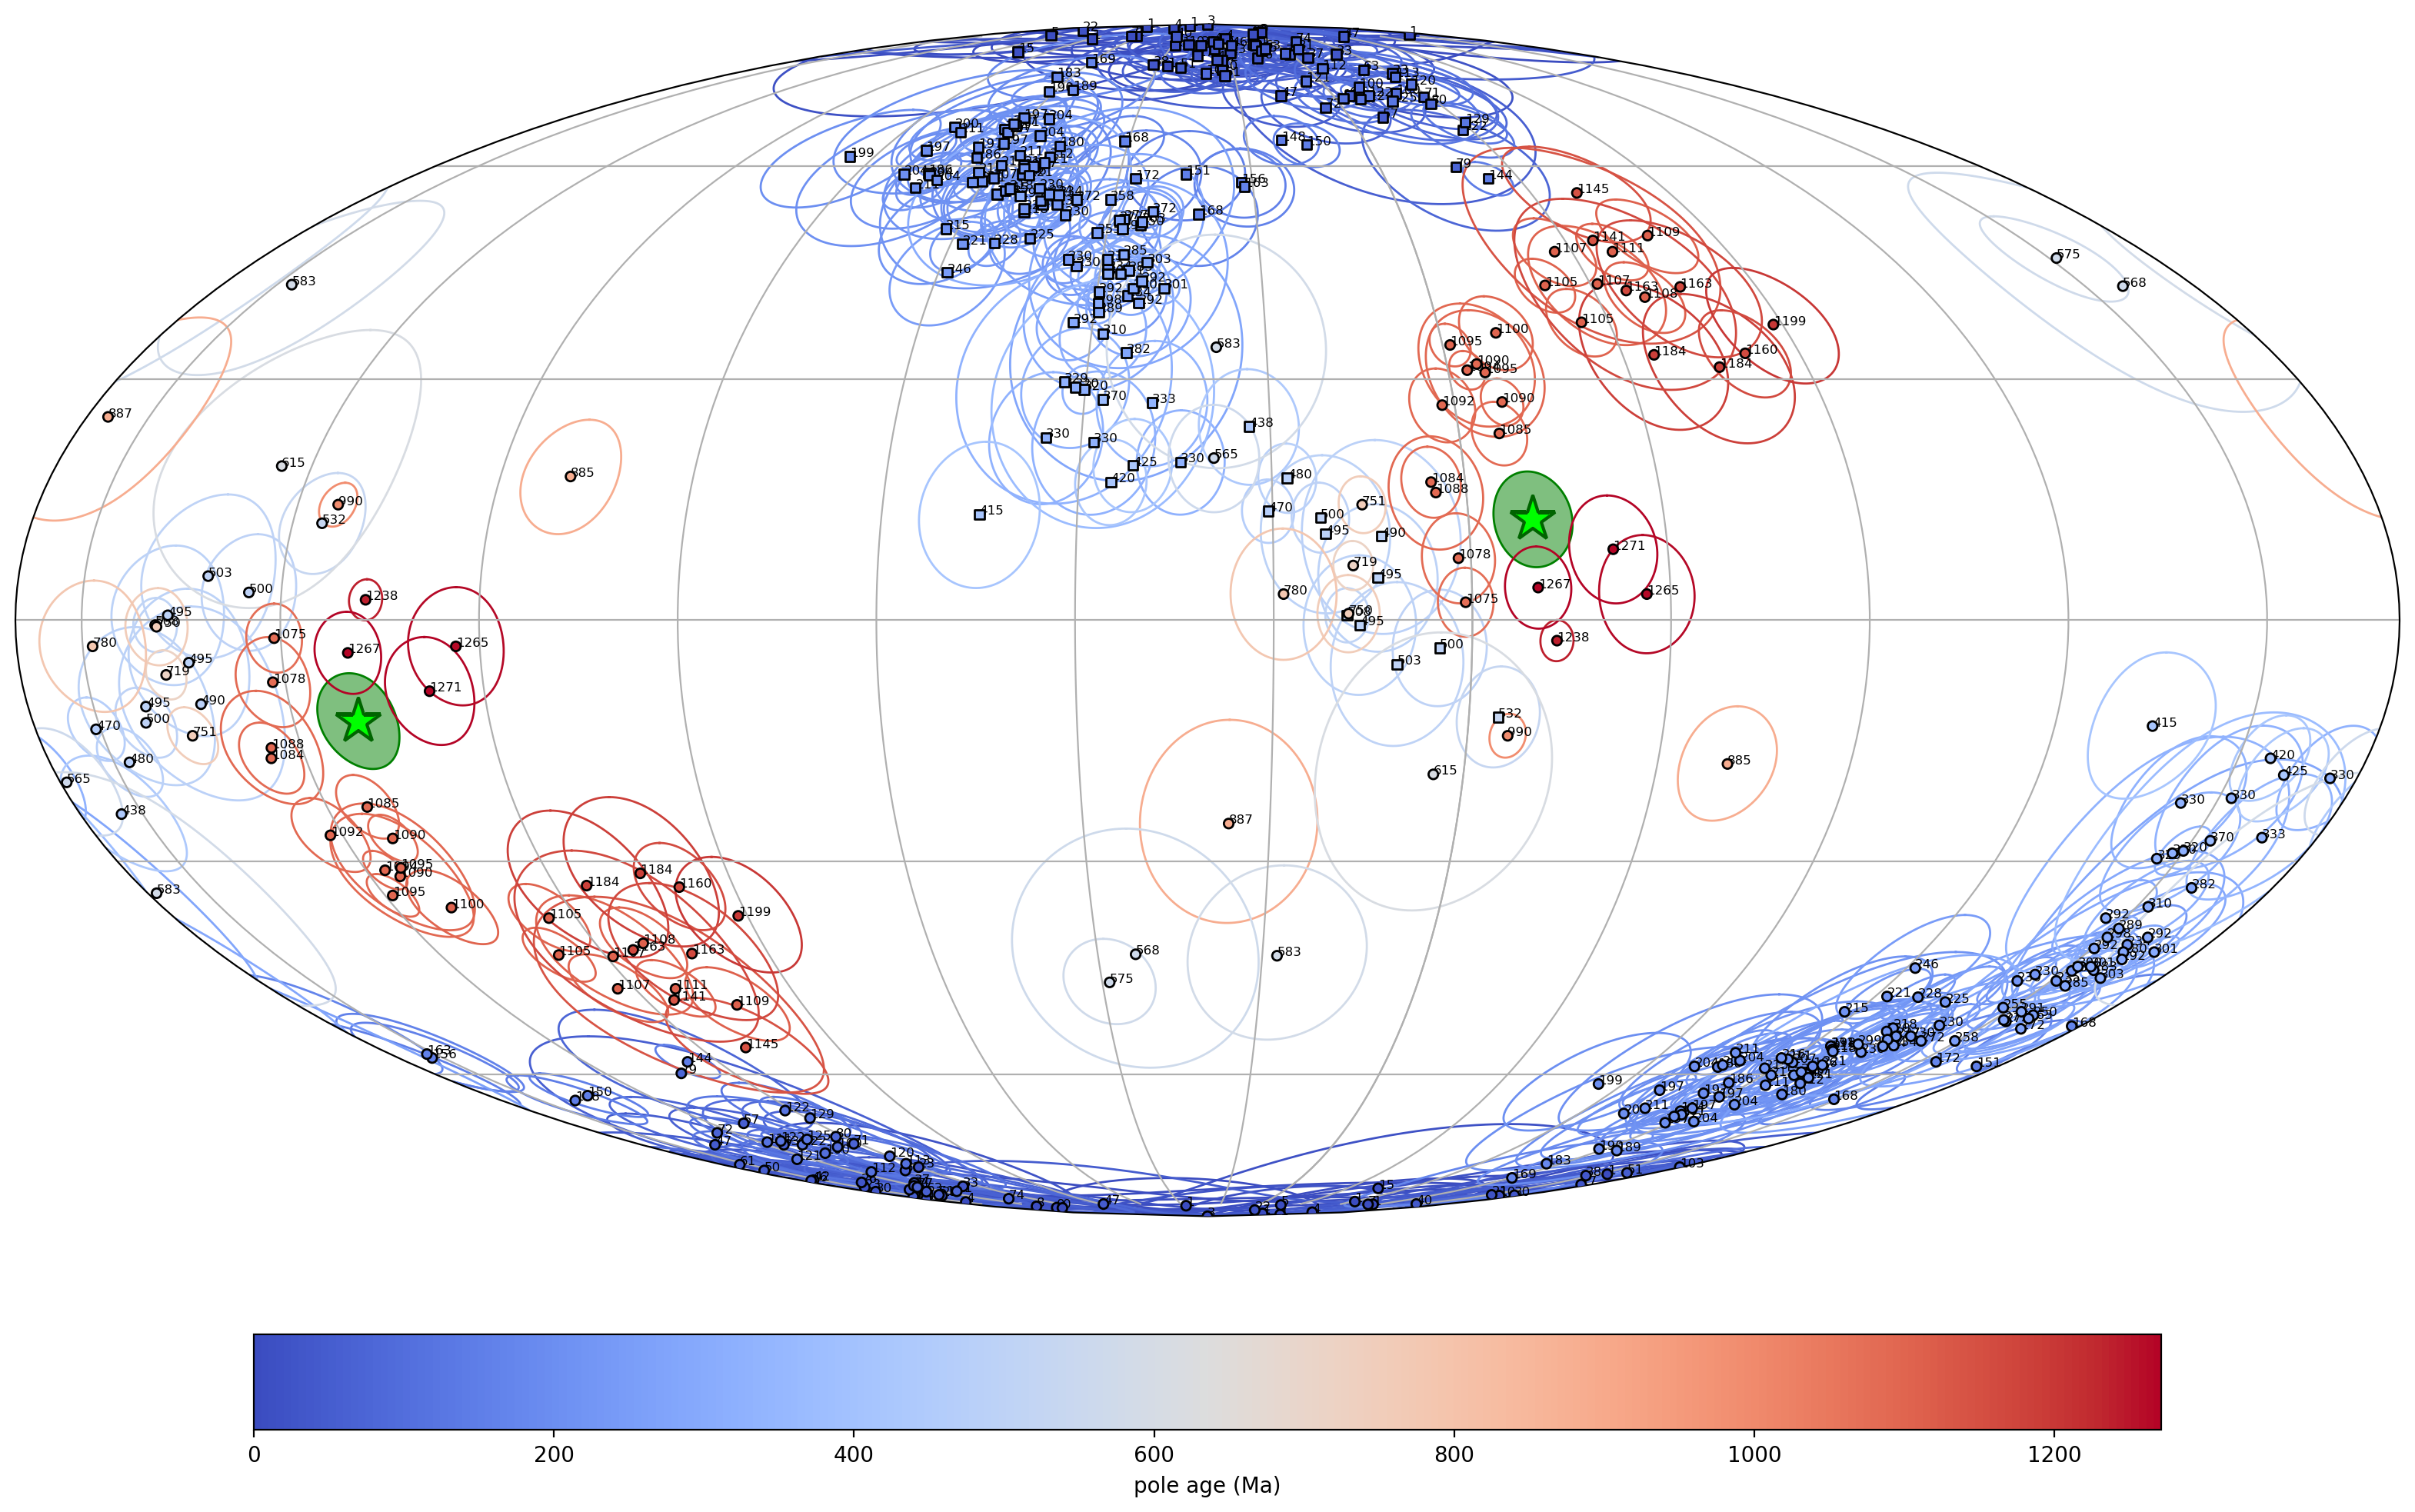

<GeoAxesSubplot:>

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
pt.plot_pole_overlap('West Gardar Dolerite Dykes', Laurentia_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rot['inc'], pole_plon=pole_rot['dec'],
                     pole_A95=pole_rot['alpha95'], pole_age=1271)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | The only age control is unpublished Rb-Sr biotite cooling ages (1263-1278 Ma) attributed to Patchett & Upton (1977); no reliable published radiometric date. |
| 2 | Techniques and statistical analysis | **1** | Sub-criterion (c) is met: N = 138 samples, B = 24 sites (>= 3 per site), K = 26.3 (within 10-70), A95 = 5.9 deg within the Deenen et al. (2011) envelope. This updates the prior compilation R2 = 0 (scored from the recreated site VGPs). |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by magnetite, characterized by alternating-field demagnetization (Piper & Stearn, 1977). |
| 4 | Field tests constrain age of magnetization | **0** | No field tests were reported (Piper & Stearn, 1977). |
| 5 | Structural control / tectonic coherence | **0** | Greenland (Gardar province); the prior compilation did not credit structural/tectonic coherence with the Laurentian craton. |
| 6 | Presence of reversals | **0** | A single, shallow northwest-directed polarity; no reversal test. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **3/7** | Grade B |

## Nordic workshop summary

The West Gardar dolerite pole is recreated as the Fisher mean of the
24 site VGPs of Piper & Stearn (1977) (computed at the sampling
locality), reproducing the prior-compilation pole (8.7 N / 201.7 E, A95 6.6). The Greenland
pole is reported in its present (Greenland) coordinates in the summary and shown
rotated into the Laurentia frame in the plots above. The age rests on unpublished
Rb-Sr biotite cooling ages (1263-1278 Ma), giving a Grade B, R = 3 pole.

In [10]:
wg_summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='West Gardar Dolerite Dykes',
    sites=dyke,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Site-mean characteristic remanent magnetization (magnetite); single shallow northwest-directed polarity',
    tests='',
    gpmdb_number='2106',
    percent_reversed=0,
    demag_code=3,
    R1=0,
    R2=1,
    R3=1,
    R4='',
    R5=0,
    R6=0,
    R7=1,
    Grade='B',
    nominal_age=1271,
    lomagage=1263,
    himagage=1278,
    REF_method='Age from unpublished Rb-Sr biotite cooling ages (1278, 1277, 1272, 1265, 1263 Ma) attributed to Patchett & Upton (1977); bounds 1263-1278 Ma, nominal 1271 Ma (Piper & Stearn, 1977).',
    POLE_AUTHORS='Piper, J. D. A., & Stearn, J. E. F.',
    YEAR=1977,
    JOURNAL='Physics of the Earth and Planetary Interiors',
    VOLUME='14',
    VPAGES='345-358',
    TITLE='Palaeomagnetism of the dyke swarms of the Gardar igneous province, south Greenland',
    COMMENT='West Gardar dolerite pole recreated as the Fisher mean of the 24 site VGPs of Piper & Stearn (1977), VGPs computed at the sampling locality (61.2N/311.7E); reproduces the prior-compilation pole (8.7 N / 201.7 E, A95 6.6). Directions only in the source; single shallow NW-directed polarity. Pole in Greenland coordinates.'
)
pt.save_nordic_summary(wg_summary, '1271_West_Gardar_dolerite')
wg_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,West Gardar Dolerite Dykes,GPMDB:2106,Site-mean characteristic remanent magnetizatio...,,0,61.2,311.7,24,138,...,1278,Age from unpublished Rb-Sr biotite cooling age...,West Gardar Dolerite Dykes,"Piper, J. D. A., & Stearn, J. E. F.",1977,Physics of the Earth and Planetary Interiors,14,345-358,Palaeomagnetism of the dyke swarms of the Gard...,West Gardar dolerite pole recreated as the Fis...
